# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [7]:
!git clone https://github.com/hershiaytoda/ds3001project


Cloning into 'ds3001project'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 59 (delta 22), reused 18 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 9.84 MiB | 8.59 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [25]:
import pandas as pd


In [26]:
df = pd.read_csv("ds3001project/data/air_fryers_clean_brand_year.csv")
print(df.head())
print(df['brand'].unique())
print(df['year'].unique())
#there are 10 unique brands
#there are 5 years, they are 2019-2023

     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119             15

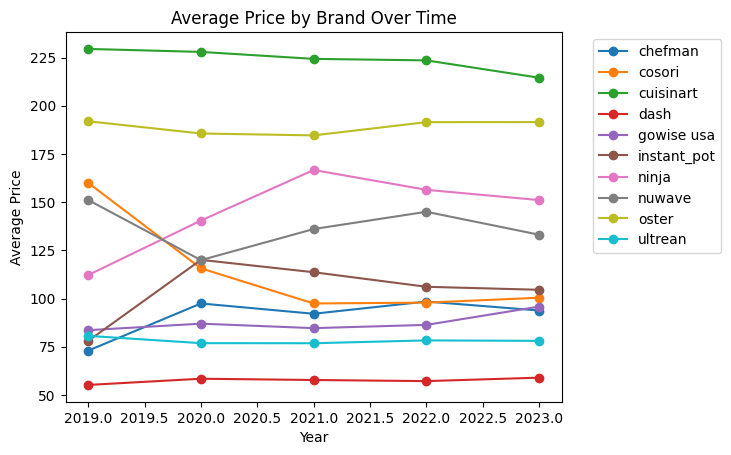

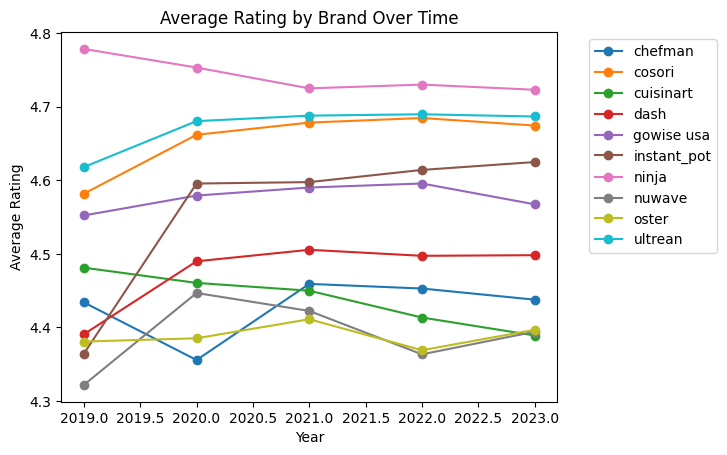

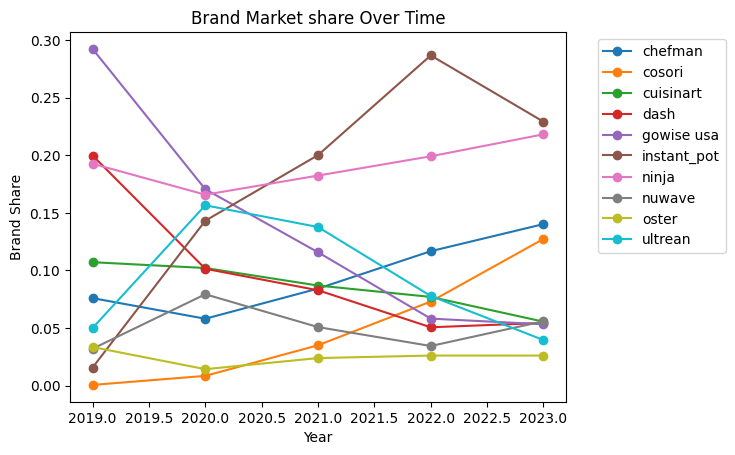

In [27]:
#plotting, question 2

import matplotlib.pyplot as plt

#avg_price
df_clean = df.drop_duplicates(subset=["year", "brand"])
df_clean = df_clean.sort_values(by=["year", "brand"])

for brand, group in df_clean.groupby("brand"):
    plt.plot(group["year"], group["avg_price"], marker="o", label=brand)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Average Price by Brand Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.show()


# avg_rating

for brand, group in df_clean.groupby("brand"):
    plt.plot(group["year"], group["avg_rating"], marker="o", label=brand)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Average Rating by Brand Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()


#brand market share
for brand, group in df_clean.groupby("brand"):
    plt.plot(group["year"], group["brand_share"], marker="o", label=brand)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Brand Market Share Over Time")
plt.xlabel("Year")
plt.ylabel("Brand Share")
plt.show()





       compact_share  dual_basket_share  oven_style_share  rotisserie_share  \
count      50.000000          50.000000         50.000000         50.000000   
mean        0.980081           0.002260          0.562647          0.070762   
std         0.068570           0.007243          0.338648          0.122542   
min         0.542017           0.000000          0.000000          0.000000   
25%         0.993128           0.000000          0.185735          0.000000   
50%         0.999191           0.000000          0.694366          0.000000   
75%         1.000000           0.000000          0.846168          0.124260   
max         1.000000           0.034520          0.973431          0.511073   

       window_share  
count     50.000000  
mean       0.036741  
std        0.115186  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        0.485465  
compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762


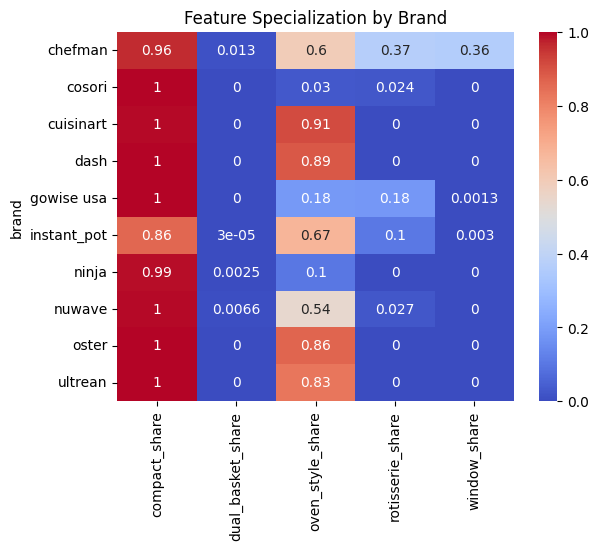

In [28]:
#Summarize the product characteristics:
#Which features are common?
#Which features are rare?
#Are there brands that seem to specialize in different product types?

feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]
print(df[feature_cols].describe())

#averages
feature_means = df[feature_cols].mean().sort_values(ascending=False)
print(feature_means)

brand_features = df.groupby("brand")[feature_cols].mean()


dominant_feature = brand_features.idxmax(axis=1)
print(dominant_feature)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(brand_features, annot=True, cmap="coolwarm")
plt.title("Feature Specialization by Brand")
plt.show()

**Market Summary**

It seems that many air fryers companies stay relatively close to general price range, although some are more consistent than others. For example, Dash air fryers are the cheapest air fryers and have stayed the cheapest over 2019 to 2023 whereas Cuisinart air fryers remained the most expensive. Other companies had more dramatic decreases in their average prices through the years such as Cosori and Nuwave. Both specifically went from around 150-160 dollars in 2019 to 115 dollars in 2020. Alternatively, the comapanies Ninja and Chefman both had sharp increases from 2019 to 2020. Strong fluctiations in the average prices align with an unstable market. As for specific market shares of each brand, it seems Oster had the most stability. Through the years, Gowise USA had the sharpest decline in market share and Instant Pot had the largest increase. Overall the market seems unstable over this time span since there are drastic changes in the share between years for almost every brand. In reference to market share and average reviews, Cosori generally had a lower market share but had higher reviews; positive reviews alone could not increase the demand suggesting an overlap between reviews and market share. Brands such as Oster have an overlap; Oster consistantly had a low market share but also lower customer reviews. On a similar note, Instant Pot recieved a sharp incline in positive ratings during 2020 and a decline in average price which resulted in an increase in market share around that time and after as well.

There does not appear to be a simple or stable relationship between price and market share, suggesting that numerous factors such as brand reputation or reviews, product features, or innovation may play a significant role in determining market success. There was no consistent conclusion due to the variety of circumstance, however we can determine that a declining or stable average price alongside good reviews can generally benefit market share whether that be an increase of stability.




## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

## 4. Results

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.